# Tusi-Couple Radial Filter — Full Walkthrough

Testing whether a geometric pre-filter (inspired by the Tusi couple — a small
circle rolling inside a larger circle) helps a CNN classify medical images
better than raw pixels, on two domains: mammography (malignant vs. benign) and
colonoscopy (polyp vs. normal tissue).

This notebook walks the whole pipeline end to end: the transform itself, both
datasets, both models, and both experiments' results, plus an efficiency
analysis. All data referenced here (`../mammography/dataset/`,
`../polyp/dataset/`) is the actual small, committed dataset the results
below were produced from — nothing needs to be downloaded to re-run this.

In [1]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path("..")
torch.manual_seed(0)

## 1. The Tusi transform

Geometric derivation: a small circle of radius `r` rolls without slipping
inside a larger circle of radius `2r`. A point on the small circle's rim
traces a straight line — a diameter of the big circle — as it rolls, and its
position along that line is `x(phi) = R*cos(phi)`: a pure cosine oscillation,
not a linear sweep.

`TusiRadialFilter` reuses that as a sampling scheme: for `N` evenly spaced
angles around a crop's center, it samples `D` points along each angle's
diameter at harmonic (cosine), phase-shifted positions — `r =
cos(2*pi*j/D + theta_i)` — instead of evenly spaced points. The phase
`theta_i` ties each diameter's sampling to its own angle, coupling angle and
radius the way a Tusi couple couples rolling angle and position.

Output: an `(N, D)` grid — row = angle, column = harmonic radial sample —
fed to the CNN in place of the raw image.

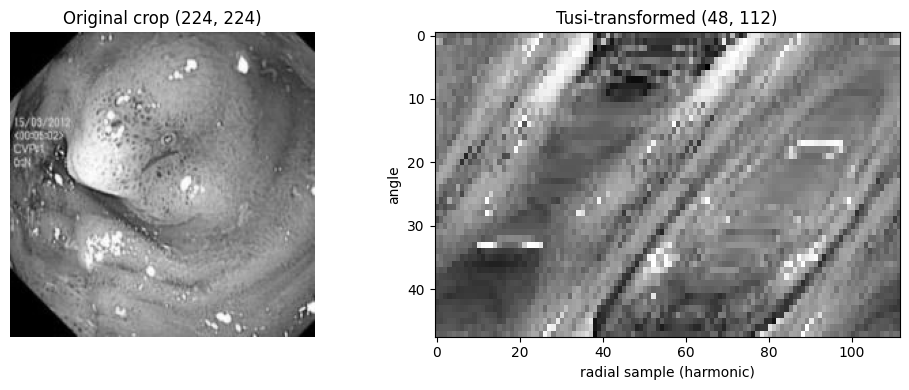

In [2]:
from core.tusi_filter import TusiRadialFilter

# demonstrate on a real polyp crop
demo_path = sorted((ROOT / "polyp/dataset/train/polyp").glob("*.jpg"))[0]
demo_img = Image.open(demo_path).convert("L")
demo_arr = np.array(demo_img).astype(np.float32) / 255.0
demo_tensor = torch.from_numpy(demo_arr).unsqueeze(0)

radial_filter = TusiRadialFilter(n_angles=48, n_radial=112)
tusi_out = radial_filter(demo_tensor)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(demo_arr, cmap="gray")
axes[0].set_title(f"Original crop {demo_arr.shape}")
axes[0].axis("off")
axes[1].imshow(tusi_out.squeeze(0).numpy(), cmap="gray", aspect="auto")
axes[1].set_title(f"Tusi-transformed {tuple(tusi_out.shape[1:])}")
axes[1].set_xlabel("radial sample (harmonic)")
axes[1].set_ylabel("angle")
plt.tight_layout()
plt.show()

## 2. The controlled comparison

Two branches, same everything except the input transform:

- **Baseline**: crop → resize → grayscale→3ch → normalize → CNN
- **Tusi**: crop → resize → grayscale → `TusiRadialFilter` → 3ch → normalize → CNN

Both use the **exact same architecture** (`TusiCompatibleCNN`) — same optimizer,
learning rate, epoch count, seed. Only the input representation differs, so any
performance gap traces back to the representation, not architecture.

In [3]:
from core.models import create_model

model = create_model("cnn")
n_params = sum(p.numel() for p in model.parameters())
print(f"TusiCompatibleCNN: {n_params:,} parameters")
print("Same architecture used for both baseline and Tusi branches, both experiments below.")
print(model)

TusiCompatibleCNN: 389,633 parameters
Same architecture used for both baseline and Tusi branches, both experiments below.
TusiCompatibleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inpla

## 3. Experiment 1 — Mammography (CBIS-DDSM)

1,696 mass lesions, `pathology` label (malignant/benign) confirmed by **biopsy**
— the clinical gold standard. Lesions cropped around their mask centroid (mask
used only to find the crop center, never seen by the model itself).

**Key finding during this experiment**: we found concrete cases where biopsy
truth diverges from visual appearance — a benign lesion with a jagged,
spiculated-looking mask, and a malignant lesion with a smooth, round mask. A
blind test (we guessed malignant/benign from 5 raw crops ourselves) scored 1/5
correct. This means no purely visual method can be expected to perfectly
classify this data — the label sometimes disagrees with the image.

In [4]:
with open(ROOT / "mammography/results/metrics.json") as f:
    mammo_metrics = json.load(f)

import pandas as pd
mammo_df = pd.DataFrame(mammo_metrics).T
mammo_df.columns = ["accuracy", "roc_auc", "sensitivity", "f1"]
mammo_df.round(3)

,accuracy,roc_auc,sensitivity,f1
baseline,0.632,0.626,0.238,0.339
tusi,0.617,0.627,0.375,0.438


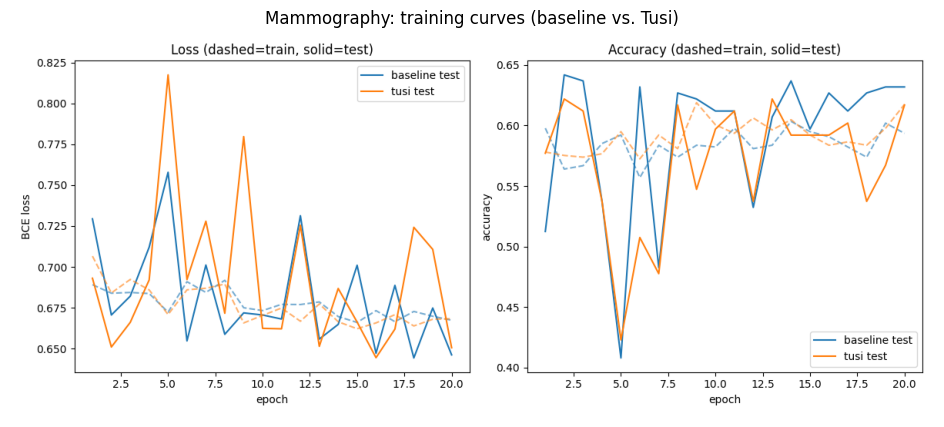

In [5]:
img = Image.open(ROOT / "mammography/results/training_curves.png")
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Mammography: training curves (baseline vs. Tusi)")
plt.show()

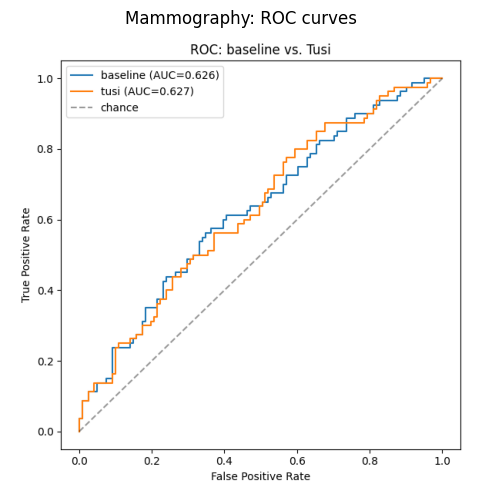

In [6]:
img = Image.open(ROOT / "mammography/results/roc_curves.png")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Mammography: ROC curves")
plt.show()

**Read**: ROC-AUC is a statistical tie (~0.62-0.63) — no strong evidence Tusi
separates the classes better overall on this dataset. But Tusi consistently
improves sensitivity (catches more actual malignant cases), the clinically
important number. Absolute performance is capped for both branches — consistent
with the appearance-vs-biopsy divergence found above, and CBIS-DDSM being a
biopsy-selected population (only ambiguous-enough cases get biopsied at all).

## 4. Experiment 2 — Colon polyps (Kvasir-SEG + HyperKvasir)

To test the core hypothesis on a structurally cleaner task, we switched
domains. A polyp's presence is confirmed by **direct endoscopic visual
annotation** — no separate test (like biopsy) that can disagree with what's in
the image. This removes the appearance-vs-truth divergence problem entirely.

- **Positive class**: Kvasir-SEG, 1,000 polyp images with pixel-level masks.
- **Negative class**: HyperKvasir `normal-cecum` + `normal-retroflex-rectum`
  (deliberately lower-GI/colon landmarks matching where polyps occur, not
  upper-GI, to avoid an organ-type shortcut).

**A real bug we caught and fixed**: the first crop version used a fixed 224px
window; 20.3% of polyp crops ended up entirely inside the polyp (no boundary
visible), 46.4% were cut off at the edge. Fixed with an adaptive crop size
(mask bounding box × 1.6 margin, resized to 224×224) — after the fix, 0%
entirely filled, 79.9% show a clean full boundary.

In [7]:
with open(ROOT / "polyp/results/metrics.json") as f:
    polyp_metrics = json.load(f)

polyp_df = pd.DataFrame(polyp_metrics).T
polyp_df.columns = ["accuracy", "roc_auc", "sensitivity", "f1"]
polyp_df.round(3)

,accuracy,roc_auc,sensitivity,f1
baseline,0.848,0.970,0.670,0.786
tusi,0.865,0.954,0.705,0.813


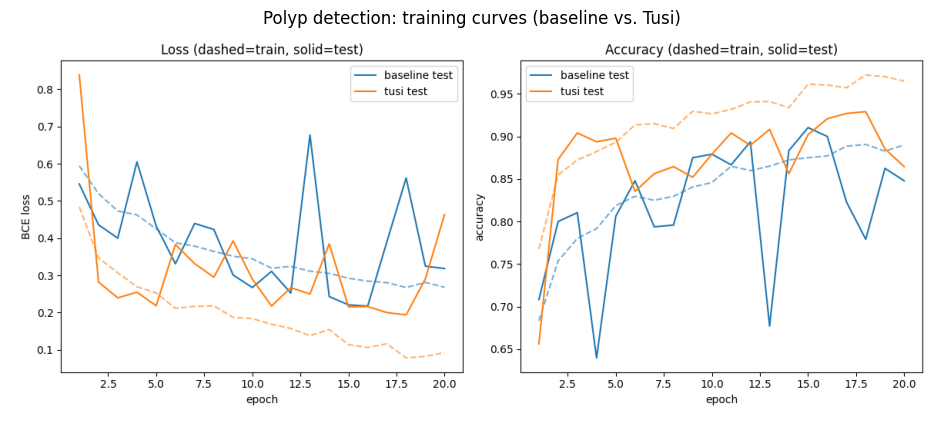

In [8]:
img = Image.open(ROOT / "polyp/results/training_curves.png")
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Polyp detection: training curves (baseline vs. Tusi)")
plt.show()

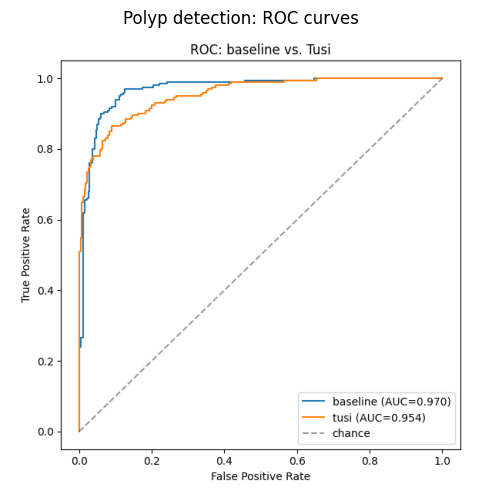

In [9]:
img = Image.open(ROOT / "polyp/results/roc_curves.png")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Polyp detection: ROC curves")
plt.show()

**Read**: both models are far stronger here than on mammography (AUC
0.95-0.97 vs ~0.62) — confirms the appearance-vs-truth divergence was a real
factor limiting the mammography result. Tusi wins 3 of 4 metrics (accuracy,
sensitivity, F1); baseline has a narrow AUC edge, but both AUCs are excellent.

### What the Tusi-filtered crops actually look like, this domain

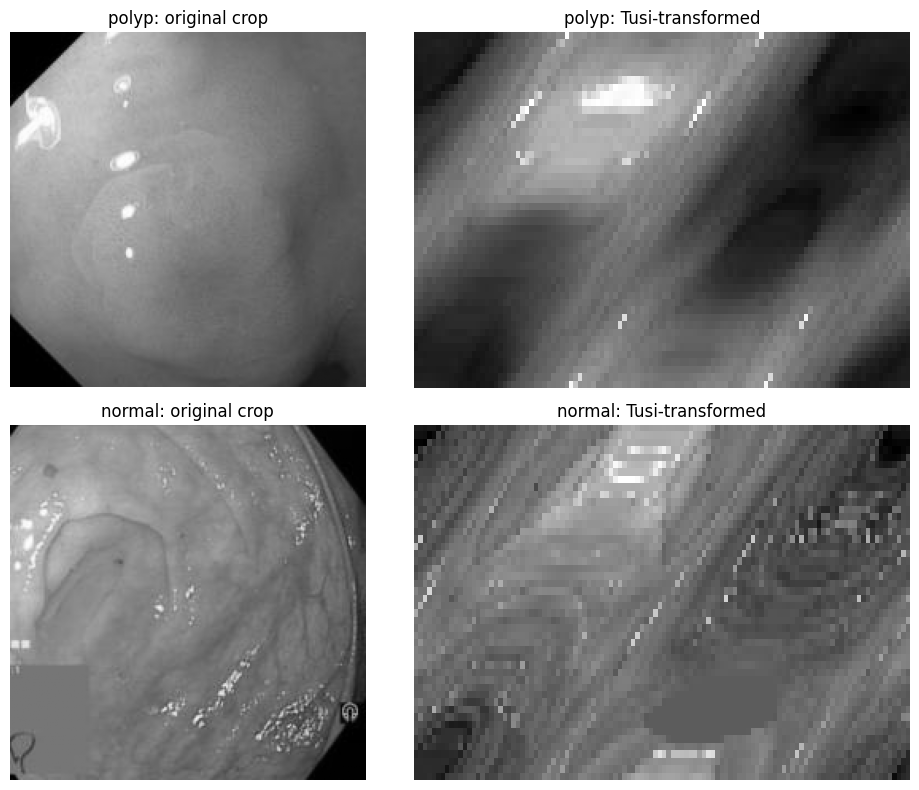

In [10]:
polyp_dir = ROOT / "polyp/dataset/train/polyp"
normal_dir = ROOT / "polyp/dataset/train/normal"
polyp_path = sorted(polyp_dir.glob("*.jpg"))[1]
normal_path = sorted(normal_dir.glob("*.jpg"))[0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for row, (path, label) in enumerate([(polyp_path, "polyp"), (normal_path, "normal")]):
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).unsqueeze(0)
    out = radial_filter(tensor).squeeze(0).numpy()

    axes[row, 0].imshow(arr, cmap="gray")
    axes[row, 0].set_title(f"{label}: original crop")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(out, cmap="gray", aspect="auto")
    axes[row, 1].set_title(f"{label}: Tusi-transformed")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

## 5. Exploratory architectures

The controlled comparison above always uses the identical `TusiCompatibleCNN`
for both branches (needed to isolate the representation as the only
variable). Separately, `explore_architectures.py` (in each pipeline) tests
two Tusi-only architectures that lean into the transform's actual structure
— not a fair A/B test, a ceiling estimate for how much the representation
can give if the model is built around it:

- **2D circular-pad CNN**: a regular 2D CNN, but the angle axis is padded
  circularly instead of with zeros, since angle 0 and angle N-1 are actually
  adjacent sweeps, not unrelated edges.
- **1D signal CNN**: treats each angle's row as its own independent 1D
  signal (a `Conv1d` per angle, weight-shared across angles), then combines
  the per-angle features across the (circular) angle axis in a second
  stage — rather than sliding a 2D kernel over the whole grid at once.

In [11]:
exploratory_metrics = {}
with open(ROOT / "mammography/results/exploratory/tusi_aware_metrics.json") as f:
    exploratory_metrics[("Mammography", "2D circular-pad")] = json.load(f)
with open(ROOT / "mammography/results/exploratory/tusi_signal_cnn_metrics.json") as f:
    exploratory_metrics[("Mammography", "1D signal")] = json.load(f)
with open(ROOT / "polyp/results/exploratory/aware/tusi_aware_cnn_metrics.json") as f:
    exploratory_metrics[("Polyp", "2D circular-pad")] = json.load(f)
with open(ROOT / "polyp/results/exploratory/signal/tusi_signal_cnn_metrics.json") as f:
    exploratory_metrics[("Polyp", "1D signal")] = json.load(f)

exploratory_df = pd.DataFrame(exploratory_metrics).T
exploratory_df.columns = ["accuracy", "roc_auc", "sensitivity", "f1"]
exploratory_df.round(3)

accuracy  roc_auc  sensitivity     f1
Mammography 2D circular-pad     0.577    0.632        0.388  0.422
            1D signal           0.617    0.615        0.350  0.421
Polyp       2D circular-pad     0.667    0.981        0.995  0.713
            1D signal           0.908    0.970        0.835  0.884

**Read**: on mammography, neither exploratory architecture beat the plain
shared CNN — architecture tweaks didn't move the needle, reinforcing that
mammography's ceiling is a data problem, not a model problem. On polyp, the
picture is different and more interesting:

- The **1D signal CNN clearly wins** across the board here — it's the best
  polyp result of any architecture tested, plain or exploratory. This is a
  reversal from mammography, where the signal approach was the weakest
  variant — consistent with a polyp being a genuine physical bump (the kind
  of clean, consistent boundary geometry the signal architecture is built to
  exploit), unlike mammography's inconsistent spiculation.
- The **2D circular-pad model has the highest AUC of anything tested**
  (0.981) but low accuracy (0.667) — it's calling almost everything "polyp"
  (99.5% sensitivity). The high AUC says the underlying discrimination is
  genuinely excellent; the low accuracy is a calibration problem at the
  default 0.5 threshold, not evidence the model is bad.

## 6. Efficiency finding

Both branches use the **identical model** (same parameter count, by design —
see section 2). But the Tusi map (48×112 = 5,376 values) is much smaller than
the raw crop (224×224 = 50,176 values), so the Tusi branch's forward pass costs
less compute.

In [12]:
from torchinfo import summary

model_a = create_model("cnn")
model_b = create_model("cnn")

s_base = summary(model_a, input_size=(1, 3, 224, 224), verbose=0)
s_tusi = summary(model_b, input_size=(1, 3, 48, 112), verbose=0)

print(f"Parameters — baseline: {s_base.total_params:,}  |  tusi: {s_tusi.total_params:,}  (identical: {s_base.total_params == s_tusi.total_params})")
print(f"Mult-adds  — baseline: {s_base.total_mult_adds/1e6:.1f}M  |  tusi: {s_tusi.total_mult_adds/1e6:.1f}M")
print(f"FLOP reduction: {s_base.total_mult_adds / s_tusi.total_mult_adds:.2f}x fewer for Tusi")

Parameters — baseline: 389,633  |  tusi: 389,633  (identical: True)
Mult-adds  — baseline: 740.0M  |  tusi: 79.3M
FLOP reduction: 9.33x fewer for Tusi


**Honest caveat**: this speed advantage isn't because "Tusi the architecture"
is inherently more efficient — it's because we chose a smaller output
resolution (`n_angles=48, n_radial=112`) than the raw crop size, a
hyperparameter choice, not an inherent property of the transform. The
legitimate claim: at ~9x fewer input values, Tusi still matched-or-beat the
full-resolution baseline on accuracy/sensitivity/F1 — an information-density
argument, not an architectural-efficiency one. (An open question, not yet
tested: does a naively downsampled raw baseline at the same pixel budget
hold up as well?)

## 7. Summary

| Domain | Baseline AUC | Tusi AUC | Tusi wins on |
|---|---|---|---|
| Mammography (CBIS-DDSM) | 0.626 | 0.627 | Sensitivity, F1 |
| Polyps (Kvasir-SEG) | 0.970 | 0.954 | Accuracy, Sensitivity, F1 |

The representation helps most consistently on **sensitivity** across both
domains and every architecture variant tried. Absolute performance is
dominated by how well the label matches visual appearance in a given domain,
not by which representation is used — confirmed by the large gap between the
two experiments here.